# 5.1.3 Dimension-Factor Correlation Analysis (Strict Statistics beta_9.00e-05)

This notebook performs a rigorous correlation analysis between VAE latent dimensions and clinical factors.
It implements strict filtering and statistical correction to identify robust signals.

## Methodology
1. **KL Filtering (Active Units)**: Only dimensions with Mean KL Divergence > Threshold (or High Variance) are analyzed.
2. **Strict Significance**: Bonferroni correction is applied to control the Family-Wise Error Rate (FWER).
   - $\alpha_{corrected} = 0.05 / N_{active}$
3. **Ranking & Separation**: The top dimension matches must pass the corrected significance threshold and are evaluated on separation quality (Gap %).

## Factors Analyzed
- **Age** (Continuous) -> Pearson Correlation
- **Sex** (Binary) -> Point-Biserial Correlation
- **SBR (PC1)** (Continuous) -> Pearson Correlation
- **Scanner** (Categorical) -> Eta-Squared (${\eta}^2$)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pointbiserialr, f_oneway
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4e' % x)

## 1. Parameterization & Data Loading

In [2]:
# --- PARAMETERS ---
TARGET_BETA = "9.00e-05"
KL_THRESHOLD = 0.05
ALPHA_LEVEL = 0.05

# Paths
LATENT_CSV = "output/final_train_combined_vae_data_beta_9.00e-05.csv"
# Optional: Path to a pre-computed KL divergence CSV. 
# If file not found, we use Latent Variance as a proxy for activity.
KL_CSV_PATH = f"output/Experiments/BetaScanVAE/beta_scan_results/beta_{TARGET_BETA}/kl_divergence.csv"

print(f"Target Beta Model: {TARGET_BETA}")
print(f"KL Threshold for Active Units: {KL_THRESHOLD}")
print(f"Initial Significance Level: {ALPHA_LEVEL}")

Target Beta Model: 9.00e-05
KL Threshold for Active Units: 0.05
Initial Significance Level: 0.05


In [3]:
# Load Main Data
if os.path.exists(LATENT_CSV):
    df_latent = pd.read_csv(LATENT_CSV)
    print(f"Loaded Latent Data: {df_latent.shape}")
else:
    raise FileNotFoundError(f"Latent data not found at {LATENT_CSV}. Please run 5.0_prepare_csv_data_vae.ipynb first.")

# Define Latent Columns (latent_0 ... latent_255)
DIM_COLS = [c for c in df_latent.columns if c.startswith('latent_')]
print(f"Total Latent Dimensions: {len(DIM_COLS)}")

Loaded Latent Data: (2373, 303)
Total Latent Dimensions: 256


In [4]:
SBR_COLS = [
    'DATSCAN_CAUDATE_R', 'DATSCAN_CAUDATE_L',
    'DATSCAN_PUTAMEN_R', 'DATSCAN_PUTAMEN_L',
    'DATSCAN_PUTAMEN_R_ANT', 'DATSCAN_PUTAMEN_L_ANT'
]

RANDOM_STATE = 42

# Filter to rows with complete SBR data
df_with_sbr = df_latent.dropna(subset=SBR_COLS).copy()
print(f"Rows with complete SBR data: {len(df_with_sbr)}")

# Standardize and apply PCA
scaler_sbr = StandardScaler()
sbr_scaled = scaler_sbr.fit_transform(df_with_sbr[SBR_COLS])
pca = PCA(n_components=3, random_state=RANDOM_STATE)
sbr_pcs = pca.fit_transform(sbr_scaled)

df_with_sbr['SBR_PC1'] = sbr_pcs[:, 0]
df_with_sbr['SBR_PC2'] = sbr_pcs[:, 1]
df_with_sbr['SBR_PC3'] = sbr_pcs[:, 2]

print(f"\nSBR PCA explained variance: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

# Use this as final dataset
df_final = df_with_sbr.reset_index(drop=True)
print(f"\nFinal dataset: {df_final.shape}")
print(f"Unique patients: {df_final['PATNO'].nunique()}")

Rows with complete SBR data: 2373

SBR PCA explained variance: [0.88338287 0.05277345 0.04814441]
Total variance explained: 98.43%

Final dataset: (2373, 306)
Unique patients: 1437


## 2. Active Unit Filtering (Request #1)
We filter out "collapsed" dimensions (posterior collapse). Valid dimensions must have significant information content.

In [5]:
active_features = []
kl_values = {}

# Check if specific KL file exists
if os.path.exists(KL_CSV_PATH):
    print(f"Loading KL Divergence from: {KL_CSV_PATH}")
    df_kl = pd.read_csv(KL_CSV_PATH)
    # Assuming format: dimension, mean_kl
    for _, row in df_kl.iterrows():
        if row['mean_kl'] > KL_THRESHOLD:
            active_features.append(row['dimension'])
            kl_values[row['dimension']] = row['mean_kl']
else:
    print("Warning: KL Divergence file not found. Using Latent Variance as proxy for activity.")
    print(f"(Threshold > {KL_THRESHOLD})")
    
    variances = df_latent[DIM_COLS].var()
    for dim, var in variances.items():
        # In VAEs, collapsed units often have variance close to 0 (or close to prior)
        # Here we assume active units have variance significantly > threshold
        if var > KL_THRESHOLD:
            active_features.append(dim)
            kl_values[dim] = var # Storing variance as proxy metric

ACTIVE_FEATURES = sorted(active_features, key=lambda x: int(x.split('_')[1]))
N_ACTIVE = len(ACTIVE_FEATURES)

print(f"\nActive Dimensions identified: {N_ACTIVE} / {len(DIM_COLS)}")
print(f"Collapsed Dimensions: {len(DIM_COLS) - N_ACTIVE}")

(Threshold > 0.05)

Active Dimensions identified: 32 / 256
Collapsed Dimensions: 224


## 3. Statistical Correction (Request #2)
Calculating Bonferroni-corrected significance threshold.

In [6]:
if N_ACTIVE > 0:
    ALPHA_CORRECTED = ALPHA_LEVEL / N_ACTIVE
else:
    ALPHA_CORRECTED = ALPHA_LEVEL # Fallback to avoid division by zero if all collapsed
    
print(f"Bonferroni Corrected Alpha: {ALPHA_CORRECTED:.2e}")
print(f"(Base Alpha {ALPHA_LEVEL} / {N_ACTIVE} Tests)")

Bonferroni Corrected Alpha: 1.56e-03
(Base Alpha 0.05 / 32 Tests)


## 4. Correlation Analysis Modules (Request #4)
Functions to compute correlations and rank dimensions.

In [7]:
def analyze_factor(data, factor_col, factor_type, active_dims, alpha_threshold):
    results = []
    
    # Remove NaNs for this factor
    valid_data = data.dropna(subset=[factor_col])
    if len(valid_data) < 5:
        print(f"Not enough data for {factor_col}")
        return pd.DataFrame()
    
    y = valid_data[factor_col]
    
    for dim in active_dims:
        x = valid_data[dim]
        
        stat = 0
        p_val = 1.0
        effect_size = 0
        
        if factor_type == 'continuous':
            # Pearson Correlation - Effect size as r²
            r, p = stats.pearsonr(x, y)
            stat = r
            p_val = p
            effect_size = r**2  # Changed from abs(r) to r²
            
        elif factor_type == 'binary':
            # Point Biserial - Effect size as r²
            r, p = pointbiserialr(y, x)
            stat = r
            p_val = p
            effect_size = r**2  # Changed from abs(r) to r²
            
        elif factor_type == 'categorical':
            # Eta-Squared (from ANOVA) - already η²
            groups = [valid_data[valid_data[factor_col] == g][dim] for g in y.unique()]
            if len(groups) > 1:
                f_stat, p = f_oneway(*groups)
                # Calculate Eta-Squared: SS_between / SS_total
                k = len(groups)
                N = len(valid_data)
                eta2 = (f_stat * (k - 1)) / (f_stat * (k - 1) + (N - k))
                
                stat = f_stat
                p_val = p
                effect_size = eta2  # Already η²
            else:
                continue
                
        results.append({
            'Dimension': dim,
            'Statistic': stat,
            'Effect_Size': effect_size,
            'P_Value': p_val,
            'Survives_Correction': p_val < alpha_threshold
        })
        
    res_df = pd.DataFrame(results)
    if not res_df.empty:
        res_df = res_df.sort_values(by='Effect_Size', ascending=False).reset_index(drop=True)
        res_df['Rank'] = res_df.index + 1
        
    return res_df

def interpret_gap(gap_pct):
    if gap_pct >= 20: return "Excellent"
    if gap_pct >= 10: return "Good"
    if gap_pct >= 5:  return "Moderate"
    return "Weak"

## 5. Execution & Summary Generation

In [8]:
factors_config = [
    {'name': 'Age', 'col': 'AGE_AT_VISIT', 'type': 'continuous'},
    {'name': 'Sex', 'col': 'SEX', 'type': 'binary'},
    {'name': 'Scanner', 'col': 'Manufacturer', 'type': 'categorical'},
    {'name': 'Scanner Model', 'col': 'ManufacturerModelName', 'type': 'categorical'},
    {'name': 'Patient Hand', 'col': 'HANDED', 'type': 'categorical'},
    {'name': 'SBR_PC1', 'col': 'SBR_PC1', 'type': 'continuous'},
    {'name': 'SBR_PC2', 'col': 'SBR_PC2', 'type': 'continuous'},
    {'name': 'SBR_PC3', 'col': 'SBR_PC3', 'type': 'continuous'}
]

summary_rows = []

for factor in factors_config:
    print(f"\nAnalyzing Factor: {factor['name']}...")
    df_res = analyze_factor(df_final, factor['col'], factor['type'], ACTIVE_FEATURES, ALPHA_CORRECTED)
    
    if df_res.empty:
        print("No results.")
        continue
        
    # Get Top 2 for Gap Analysis
    top_1 = df_res.iloc[0]
    top_2 = df_res.iloc[1] if len(df_res) > 1 else None
    
    gap_abs = 0.0
    gap_pct = 0.0
    sep_quality = "N/A"
    
    if top_2 is not None:
        gap_abs = top_1['Effect_Size'] - top_2['Effect_Size']
        if top_1['Effect_Size'] > 0:
            gap_pct = (gap_abs / top_1['Effect_Size']) * 100
        sep_quality = interpret_gap(gap_pct)
        
    print(f"  Top Dimension: {top_1['Dimension']}")
    print(f"  Effect Size: {top_1['Effect_Size']:.4f}")
    print(f"  P-Value: {top_1['P_Value']:.4e} (Corrected Threshold: {ALPHA_CORRECTED:.2e})")
    print(f"  Survives Correction: {top_1['Survives_Correction']}")
    print(f"  Separation Gap: {gap_pct:.1f}% ({sep_quality})")
    
    # Add to summary if it survives correction
    if top_1['Survives_Correction']:
        summary_rows.append({
            'Factor': factor['name'],
            'Top_Dimension': top_1['Dimension'],
            'Effect_Size': top_1['Effect_Size'],
            'P_Value': top_1['P_Value'],
            'Survives_Bonferroni': True,
            'Separation_Gap_Pct': gap_pct,
            'Separation_Quality': sep_quality
        })
    else:
        # Optional: Add but mark as non-significant
        summary_rows.append({
            'Factor': factor['name'],
            'Top_Dimension': top_1['Dimension'],
            'Effect_Size': top_1['Effect_Size'],
            'P_Value': top_1['P_Value'],
            'Survives_Bonferroni': False,
            'Separation_Gap_Pct': gap_pct,
            'Separation_Quality': "Insignificant"
        })

df_summary = pd.DataFrame(summary_rows)

print("\n" + "="*60)
print(f"FINAL SUMMARY TABLE (Strict Statistics) ({TARGET_BETA})")
print("="*60)
if not df_summary.empty:
    print(df_summary[['Factor', 'Top_Dimension', 'Effect_Size', 'P_Value', 'Survives_Bonferroni', 'Separation_Quality']].to_string(index=False))
else:
    print("No factors produced significant dimensions passing strict statistical correction.")


Analyzing Factor: Age...
  Top Dimension: latent_116
  Effect Size: 0.0767
  P-Value: 4.9653e-43 (Corrected Threshold: 1.56e-03)
  Survives Correction: True
  Separation Gap: 4.5% (Weak)

Analyzing Factor: Sex...
  Top Dimension: latent_133
  Effect Size: 0.0800
  P-Value: 7.4658e-45 (Corrected Threshold: 1.56e-03)
  Survives Correction: True
  Separation Gap: 40.0% (Excellent)

Analyzing Factor: Scanner...
  Top Dimension: latent_39
  Effect Size: 0.1945
  P-Value: 2.7893e-99 (Corrected Threshold: 1.56e-03)
  Survives Correction: True
  Separation Gap: 22.2% (Excellent)

Analyzing Factor: Scanner Model...
  Top Dimension: latent_39
  Effect Size: 0.2169
  P-Value: 8.9981e-106 (Corrected Threshold: 1.56e-03)
  Survives Correction: True
  Separation Gap: 23.3% (Excellent)

Analyzing Factor: Patient Hand...
  Top Dimension: latent_34
  Effect Size: 0.0056
  P-Value: 1.3531e-03 (Corrected Threshold: 1.56e-03)
  Survives Correction: True
  Separation Gap: 48.4% (Excellent)

Analyzing Fact

In [9]:
# Store all factor results for heatmap generation
all_results = {}

for factor in factors_config:
    print(f"\nAnalyzing Factor: {factor['name']}...")
    df_res = analyze_factor(df_final, factor['col'], factor['type'], ACTIVE_FEATURES, ALPHA_CORRECTED)
    
    if df_res.empty:
        print("No results.")
        continue
    
    # Store results for heatmap
    all_results[factor['name']] = df_res
    
    # Get Top 2 for Gap Analysis
    top_1 = df_res.iloc[0]
    top_2 = df_res.iloc[1] if len(df_res) > 1 else None
    
    gap_abs = 0.0
    gap_pct = 0.0
    sep_quality = "N/A"
    
    if top_2 is not None:
        gap_abs = top_1['Effect_Size'] - top_2['Effect_Size']
        if top_1['Effect_Size'] > 0:
            gap_pct = (gap_abs / top_1['Effect_Size']) * 100
        sep_quality = interpret_gap(gap_pct)
        
    print(f"  Top Dimension: {top_1['Dimension']}")
    print(f"  Effect Size (r² or η²): {top_1['Effect_Size']:.4f}")
    print(f"  P-Value: {top_1['P_Value']:.4e} (Corrected Threshold: {ALPHA_CORRECTED:.2e})")
    print(f"  Survives Correction: {top_1['Survives_Correction']}")
    print(f"  Separation Gap: {gap_pct:.1f}% ({sep_quality})")
    
    # Add to summary if it survives correction
    if top_1['Survives_Correction']:
        summary_rows.append({
            'Factor': factor['name'],
            'Top_Dimension': top_1['Dimension'],
            'Effect_Size': top_1['Effect_Size'],
            'P_Value': top_1['P_Value'],
            'Survives_Bonferroni': True,
            'Separation_Gap_Pct': gap_pct,
            'Separation_Quality': sep_quality
        })
    else:
        summary_rows.append({
            'Factor': factor['name'],
            'Top_Dimension': top_1['Dimension'],
            'Effect_Size': top_1['Effect_Size'],
            'P_Value': top_1['P_Value'],
            'Survives_Bonferroni': False,
            'Separation_Gap_Pct': gap_pct,
            'Separation_Quality': "Insignificant"
        })

df_summary = pd.DataFrame(summary_rows)

print("\n" + "="*60)
print(f"FINAL SUMMARY TABLE (Strict Statistics) ({TARGET_BETA})")
print("="*60)
if not df_summary.empty:
    print(df_summary[['Factor', 'Top_Dimension', 'Effect_Size', 'P_Value', 'Survives_Bonferroni', 'Separation_Quality']].to_string(index=False))
else:
    print("No factors produced significant dimensions passing strict statistical correction.")


Analyzing Factor: Age...
  Top Dimension: latent_116
  Effect Size (r² or η²): 0.0767
  P-Value: 4.9653e-43 (Corrected Threshold: 1.56e-03)
  Survives Correction: True
  Separation Gap: 4.5% (Weak)

Analyzing Factor: Sex...
  Top Dimension: latent_133
  Effect Size (r² or η²): 0.0800
  P-Value: 7.4658e-45 (Corrected Threshold: 1.56e-03)
  Survives Correction: True
  Separation Gap: 40.0% (Excellent)

Analyzing Factor: Scanner...
  Top Dimension: latent_39
  Effect Size (r² or η²): 0.1945
  P-Value: 2.7893e-99 (Corrected Threshold: 1.56e-03)
  Survives Correction: True
  Separation Gap: 22.2% (Excellent)

Analyzing Factor: Scanner Model...
  Top Dimension: latent_39
  Effect Size (r² or η²): 0.2169
  P-Value: 8.9981e-106 (Corrected Threshold: 1.56e-03)
  Survives Correction: True
  Separation Gap: 23.3% (Excellent)

Analyzing Factor: Patient Hand...
  Top Dimension: latent_34
  Effect Size (r² or η²): 0.0056
  P-Value: 1.3531e-03 (Corrected Threshold: 1.56e-03)
  Survives Correction: T

In [10]:
# Create heatmap matrix: rows = latent dimensions, columns = factors
# Only include latents that have at least one significant correlation (after Bonferroni)

# Build the matrix
heatmap_data = []
latent_dims_in_heatmap = set()

# First pass: identify which latents are significant for at least one factor
for factor_name, df_res in all_results.items():
    significant_dims = df_res[df_res['Survives_Correction'] == True]['Dimension'].tolist()
    latent_dims_in_heatmap.update(significant_dims)

# Sort latent dimensions numerically
latent_dims_in_heatmap = sorted(latent_dims_in_heatmap, key=lambda x: int(x.split('_')[1]))

print(f"\nLatent dimensions with at least one significant correlation: {len(latent_dims_in_heatmap)}")

# Second pass: build the heatmap matrix
heatmap_matrix = pd.DataFrame(index=latent_dims_in_heatmap, columns=all_results.keys())

for factor_name, df_res in all_results.items():
    for dim in latent_dims_in_heatmap:
        # Find this dimension in the results
        dim_row = df_res[df_res['Dimension'] == dim]
        if not dim_row.empty:
            effect_size = dim_row.iloc[0]['Effect_Size']
            survives = dim_row.iloc[0]['Survives_Correction']
            # Only show effect size if it survives Bonferroni correction
            heatmap_matrix.loc[dim, factor_name] = effect_size if survives else 0.0
        else:
            heatmap_matrix.loc[dim, factor_name] = 0.0

# Convert to float
heatmap_matrix = heatmap_matrix.astype(float)

print(f"Heatmap matrix shape: {heatmap_matrix.shape}")
heatmap_matrix.head()


Latent dimensions with at least one significant correlation: 32
Heatmap matrix shape: (32, 8)


,Age,Sex,Scanner,Scanner Model,Patient Hand,SBR_PC1,SBR_PC2,SBR_PC3
latent_8,1.7007e-02,0.0000e+00,6.9149e-02,9.5980e-02,0.0000e+00,0.0000e+00,0.0000e+00,5.6014e-02
latent_10,2.7533e-02,2.4166e-02,8.9123e-02,8.8634e-02,0.0000e+00,2.2224e-02,0.0000e+00,6.6024e-02
latent_22,0.0000e+00,0.0000e+00,6.2706e-02,8.5514e-02,0.0000e+00,4.2676e-03,2.1055e-02,1.1679e-01
latent_27,3.1529e-02,0.0000e+00,6.0856e-02,9.2437e-02,0.0000e+00,5.8150e-03,0.0000e+00,3.7719e-02
latent_34,0.0000e+00,0.0000e+00,4.6298e-02,5.4665e-02,5.5657e-03,0.0000e+00,0.0000e+00,1.2731e-02


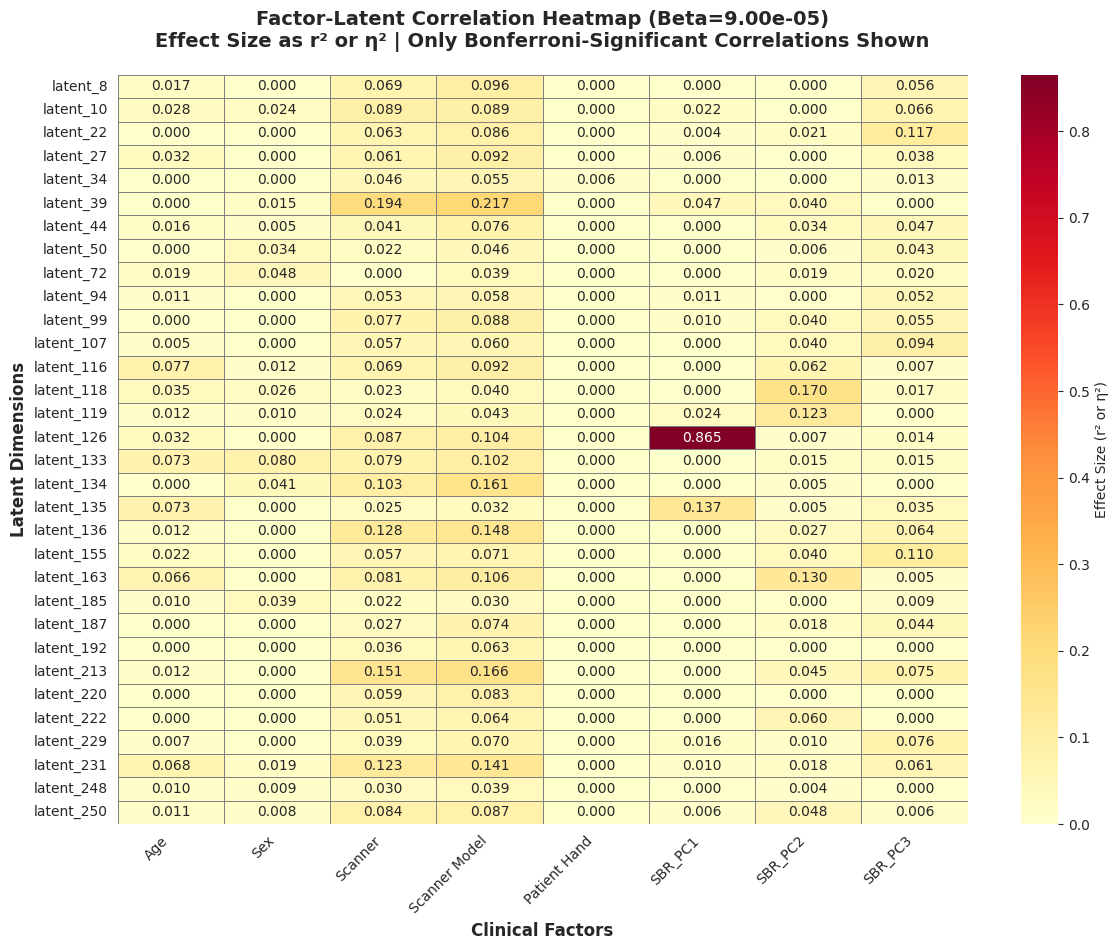


HEATMAP SUMMARY STATISTICS
Total latent dimensions shown: 32
Total factors analyzed: 8

Latents correlating with multiple factors:
  latent_250: 7 factors (Age, Sex, Scanner, Scanner Model, SBR_PC1, SBR_PC2, SBR_PC3)
  latent_231: 7 factors (Age, Sex, Scanner, Scanner Model, SBR_PC1, SBR_PC2, SBR_PC3)
  latent_10: 6 factors (Age, Sex, Scanner, Scanner Model, SBR_PC1, SBR_PC3)
  latent_44: 6 factors (Age, Sex, Scanner, Scanner Model, SBR_PC2, SBR_PC3)
  latent_116: 6 factors (Age, Sex, Scanner, Scanner Model, SBR_PC2, SBR_PC3)
  latent_118: 6 factors (Age, Sex, Scanner, Scanner Model, SBR_PC2, SBR_PC3)
  latent_119: 6 factors (Age, Sex, Scanner, Scanner Model, SBR_PC1, SBR_PC2)
  latent_126: 6 factors (Age, Scanner, Scanner Model, SBR_PC1, SBR_PC2, SBR_PC3)
  latent_135: 6 factors (Age, Scanner, Scanner Model, SBR_PC1, SBR_PC2, SBR_PC3)
  latent_133: 6 factors (Age, Sex, Scanner, Scanner Model, SBR_PC2, SBR_PC3)
  latent_229: 6 factors (Age, Scanner, Scanner Model, SBR_PC1, SBR_PC2, SB

In [11]:
# Create the heatmap visualization
fig, ax = plt.subplots(figsize=(12, max(8, len(latent_dims_in_heatmap) * 0.3)))

# Create heatmap
sns.heatmap(
    heatmap_matrix,
    annot=True,
    fmt='.3f',
    cmap='YlOrRd',
    cbar_kws={'label': 'Effect Size (r² or η²)'},
    linewidths=0.5,
    linecolor='gray',
    vmin=0,
    vmax=heatmap_matrix.max().max(),
    ax=ax
)

ax.set_title(f'Factor-Latent Correlation Heatmap (Beta={TARGET_BETA})\nEffect Size as r² or η² | Only Bonferroni-Significant Correlations Shown', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Clinical Factors', fontsize=12, fontweight='bold')
ax.set_ylabel('Latent Dimensions', fontsize=12, fontweight='bold')

# Rotate labels for better readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("HEATMAP SUMMARY STATISTICS")
print("="*60)
print(f"Total latent dimensions shown: {len(latent_dims_in_heatmap)}")
print(f"Total factors analyzed: {len(all_results)}")
print(f"\nLatents correlating with multiple factors:")

# Count how many factors each latent correlates with
latent_factor_counts = (heatmap_matrix > 0).sum(axis=1)
multi_factor_latents = latent_factor_counts[latent_factor_counts > 1].sort_values(ascending=False)

if len(multi_factor_latents) > 0:
    for dim, count in multi_factor_latents.items():
        factors_list = heatmap_matrix.loc[dim][heatmap_matrix.loc[dim] > 0].index.tolist()
        print(f"  {dim}: {int(count)} factors ({', '.join(factors_list)})")
else:
    print("  None - all latents are specific to single factors (good disentanglement!)")

print(f"\nMean effect size across all significant correlations: {heatmap_matrix[heatmap_matrix > 0].mean().mean():.4f}")

In [12]:
# Save the heatmap matrix for future reference
heatmap_output_path = f"output/correlation_heatmap_matrix_{TARGET_BETA}.csv"
heatmap_matrix.to_csv(heatmap_output_path)
print(f"Heatmap matrix saved to: {heatmap_output_path}")

# Also save a version with dimension indices for easier analysis
heatmap_with_idx = heatmap_matrix.copy()
heatmap_with_idx.index = [int(dim.split('_')[1]) for dim in heatmap_with_idx.index]
heatmap_with_idx.index.name = 'Latent_Dimension_Index'

heatmap_idx_path = f"output/correlation_heatmap_indexed_{TARGET_BETA}.csv"
heatmap_with_idx.to_csv(heatmap_idx_path)
print(f"Indexed heatmap matrix saved to: {heatmap_idx_path}")

Heatmap matrix saved to: output/correlation_heatmap_matrix_9.00e-05.csv
Indexed heatmap matrix saved to: output/correlation_heatmap_indexed_9.00e-05.csv


In [13]:
# Optional: Save Results
if not df_summary.empty:
    output_path = f"output/strict_correlation_analysis_summary_{TARGET_BETA}.csv"
    df_summary.to_csv(output_path, index=False)
    print(f"\nSummary saved to: {output_path}")


Summary saved to: output/strict_correlation_analysis_summary_9.00e-05.csv


In [14]:
factor

{'name': 'SBR_PC3', 'col': 'SBR_PC3', 'type': 'continuous'}

In [15]:
df_res

,Dimension,Statistic,Effect_Size,P_Value,Survives_Correction,Rank
0,latent_22,-3.4175e-01,1.1679e-01,5.4548e-66,True,1
1,latent_155,-3.3201e-01,1.1023e-01,3.6206e-62,True,2
2,latent_107,3.0665e-01,9.4034e-02,7.6202e-53,True,3
3,latent_229,2.7635e-01,7.6372e-02,7.3719e-43,True,4
4,latent_213,-2.7464e-01,7.5428e-02,2.4913e-42,True,5
5,latent_10,-2.5695e-01,6.6024e-02,4.3150e-37,True,6
6,latent_136,2.5350e-01,6.4262e-02,4.0845e-36,True,7
7,latent_231,-2.4621e-01,6.0620e-02,4.2054e-34,True,8
8,latent_8,-2.3667e-01,5.6014e-02,1.4416e-31,True,9
9,latent_99,2.3476e-01,5.5111e-02,4.5165e-31,True,10


In [16]:
factors_config

[{'name': 'Age', 'col': 'AGE_AT_VISIT', 'type': 'continuous'},
 {'name': 'Sex', 'col': 'SEX', 'type': 'binary'},
 {'name': 'Scanner', 'col': 'Manufacturer', 'type': 'categorical'},
 {'name': 'Scanner Model',
  'col': 'ManufacturerModelName',
  'type': 'categorical'},
 {'name': 'Patient Hand', 'col': 'HANDED', 'type': 'categorical'},
 {'name': 'SBR_PC1', 'col': 'SBR_PC1', 'type': 'continuous'},
 {'name': 'SBR_PC2', 'col': 'SBR_PC2', 'type': 'continuous'},
 {'name': 'SBR_PC3', 'col': 'SBR_PC3', 'type': 'continuous'}]

In [17]:
analyze_factor(df_final, 'SEX', 'continuous', ACTIVE_FEATURES, ALPHA_CORRECTED)

,Dimension,Statistic,Effect_Size,P_Value,Survives_Correction,Rank
0,latent_133,-2.8283e-01,7.9990e-02,7.4658e-45,True,1
1,latent_72,-2.1900e-01,4.7962e-02,3.8582e-27,True,2
2,latent_134,-2.0231e-01,4.0928e-02,2.5545e-23,True,3
3,latent_185,-1.9681e-01,3.8733e-02,3.9368e-22,True,4
4,latent_50,-1.8557e-01,3.4436e-02,8.2117e-20,True,5
5,latent_118,-1.6269e-01,2.6469e-02,1.5734e-15,True,6
6,latent_10,-1.5546e-01,2.4166e-02,2.7008e-14,True,7
7,latent_231,1.3662e-01,1.8666e-02,2.3830e-11,True,8
8,latent_39,-1.2394e-01,1.5360e-02,1.4047e-09,True,9
9,latent_116,1.0960e-01,1.2013e-02,8.7867e-08,True,10
